# Air Quality Index Prediction Using Machine Learning

### Project Description
This project predicts Air Quality Index (AQI) using Machine Learning techniques. The dataset contains pollutant AQI values such as CO, Ozone, NO2, and PM2.5. Different regression models are trained and compared to identify the best-performing model.

# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset

In [2]:
df = pd.read_csv("AQI_Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# 3. Dataset Overview

In [3]:
print("First 5 Records")

df.head()

First 5 Records


,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,lat,lng
0,1,36,0,51,44.7444,44.2031
1,1,5,1,41,-5.2900,-44.4900
2,1,5,1,41,-11.2958,-41.9869
3,1,39,2,66,37.1667,15.1833
4,1,34,0,20,53.0167,20.8833


In [4]:
print("Dataset Shape")

print(df.shape)

Dataset Shape
(16695, 6)


In [5]:
print("Column Names")

print(df.columns.tolist())

Column Names
['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value', 'lat', 'lng']


In [6]:
print("Dataset Information")

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16695 entries, 0 to 16694
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CO AQI Value     16695 non-null  int64  
 1   Ozone AQI Value  16695 non-null  int64  
 2   NO2 AQI Value    16695 non-null  int64  
 3   PM2.5 AQI Value  16695 non-null  int64  
 4   lat              16695 non-null  float64
 5   lng              16695 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 782.7 KB


# 4. Data Cleaning

In [7]:
df.columns = df.columns.str.strip()

In [8]:
print("Missing Values")

print(df.isnull().sum())

Missing Values
CO AQI Value       0
Ozone AQI Value    0
NO2 AQI Value      0
PM2.5 AQI Value    0
lat                0
lng                0
dtype: int64


# 5. Calculate Overall AQI

In [9]:
df["AQI Value"] = df[
    [
        "CO AQI Value",
        "Ozone AQI Value",
        "NO2 AQI Value",
        "PM2.5 AQI Value"
    ]
].max(axis=1)

In [10]:
df.head()

,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,lat,lng,AQI Value
0,1,36,0,51,44.7444,44.2031,51
1,1,5,1,41,-5.2900,-44.4900,41
2,1,5,1,41,-11.2958,-41.9869,41
3,1,39,2,66,37.1667,15.1833,66
4,1,34,0,20,53.0167,20.8833,34


# 6. AQI Category Classification

In [11]:
def classify_aqi(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Moderate"

    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"

    elif aqi <= 200:
        return "Unhealthy"

    elif aqi <= 300:
        return "Very Unhealthy"

    else:
        return "Hazardous"

In [12]:
df["AQI Category"] = df["AQI Value"].apply(classify_aqi)

In [13]:
df.head()

,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,lat,lng,AQI Value,AQI Category
0,1,36,0,51,44.7444,44.2031,51,Moderate
1,1,5,1,41,-5.2900,-44.4900,41,Good
2,1,5,1,41,-11.2958,-41.9869,41,Good
3,1,39,2,66,37.1667,15.1833,66,Moderate
4,1,34,0,20,53.0167,20.8833,34,Good


# 7. AQI Distribution Analysis

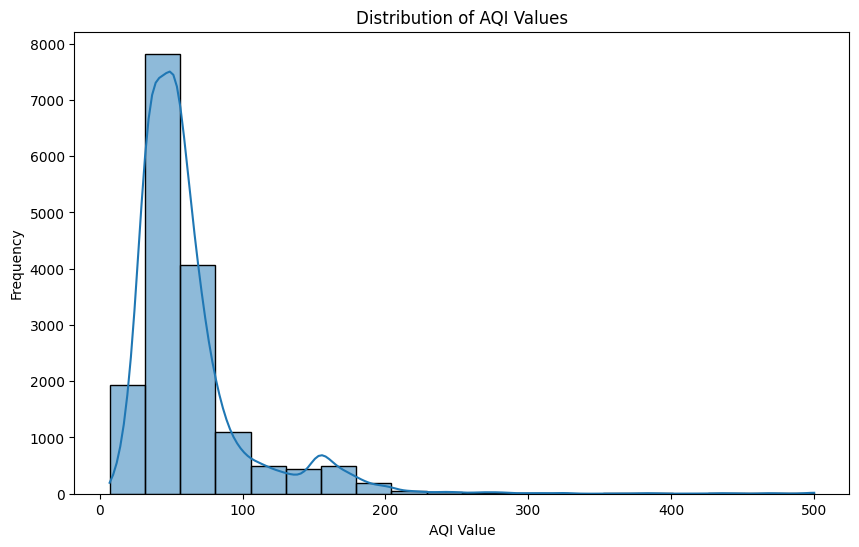

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["AQI Value"],
    bins=20,
    kde=True
)

plt.title("Distribution of AQI Values")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")

plt.show()

# 8. AQI Category Distribution

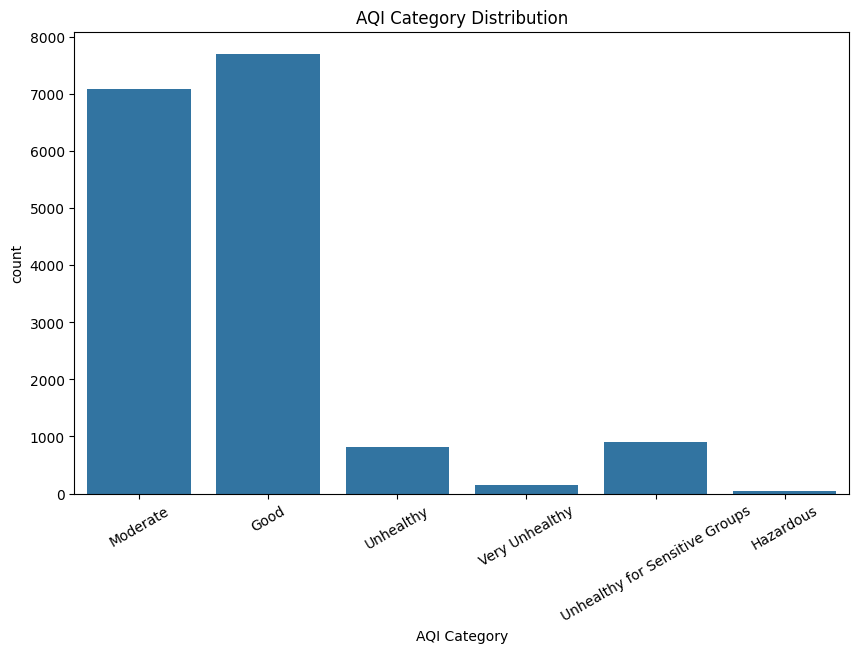

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="AQI Category"
)

plt.xticks(rotation=30)

plt.title("AQI Category Distribution")

plt.show()

# 9. Correlation Heatmap

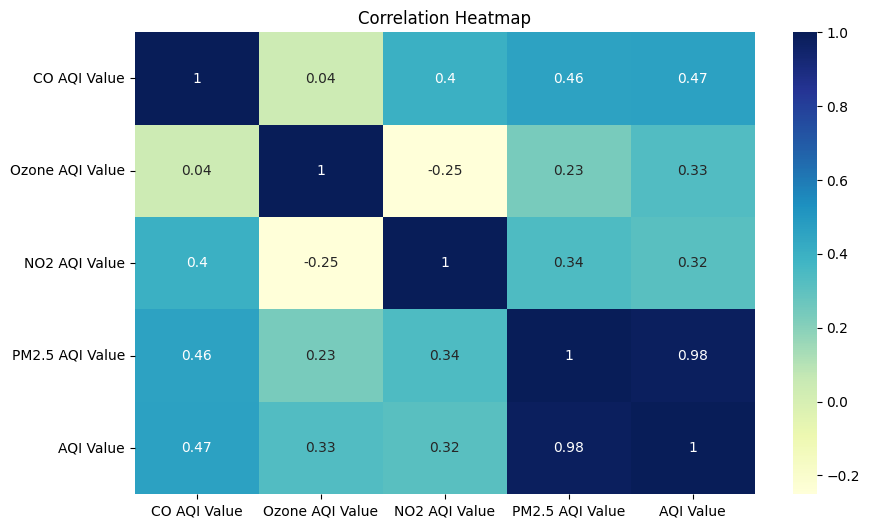

In [16]:
corr = df[
    [
        "CO AQI Value",
        "Ozone AQI Value",
        "NO2 AQI Value",
        "PM2.5 AQI Value",
        "AQI Value"
    ]
].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Correlation Heatmap")

plt.show()

# 10. Feature Selection

In [17]:
X = df[
    [
        "CO AQI Value",
        "Ozone AQI Value",
        "NO2 AQI Value",
        "PM2.5 AQI Value",
        "lat",
        "lng"
    ]
]

y = df["AQI Value"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (16695, 6)
Target Shape: (16695,)


# 11. Train-Test Split


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (13356, 6)
Testing Data: (3339, 6)


# 12. Machine Learning Model Training


In [19]:
models = {

    "Random Forest":
    RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Linear Regression":
    LinearRegression(),

    "Gradient Boosting":
    GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Support Vector Regressor":
    SVR()
}

# 13. Model Evaluation

In [20]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    results[name] = {
        "MAE": mae,
        "R2 Score": r2
    }

    print("\n", "="*50)
    print("Model:", name)
    print("MAE:", round(mae, 4))
    print("R2 Score:", round(r2, 4))


Model: Random Forest
MAE: 0.0444
R2 Score: 0.9999

Model: Linear Regression
MAE: 4.1203
R2 Score: 0.9769

Model: Gradient Boosting
MAE: 0.7625
R2 Score: 0.9991

Model: Support Vector Regressor
MAE: 2.882
R2 Score: 0.8448


# 14. Model Comparison

In [21]:
results_df = pd.DataFrame(results).T

results_df

,MAE,R2 Score
Random Forest,0.044412,0.999933
Linear Regression,4.120265,0.976883
Gradient Boosting,0.762476,0.999146
Support Vector Regressor,2.882001,0.844834


In [22]:
results_df

,MAE,R2 Score
Random Forest,0.044412,0.999933
Linear Regression,4.120265,0.976883
Gradient Boosting,0.762476,0.999146
Support Vector Regressor,2.882001,0.844834


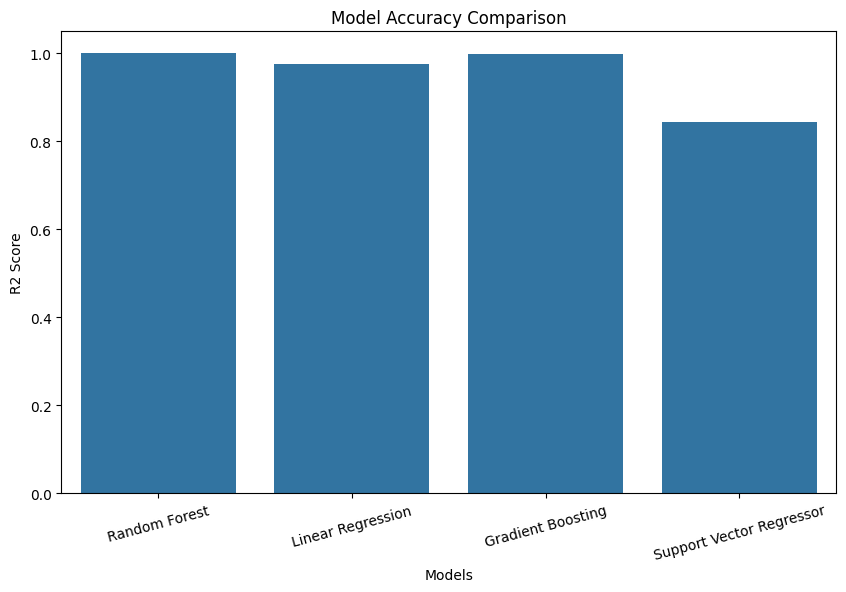

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=results_df.index,
    y=results_df["R2 Score"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.xticks(rotation=15)

plt.show()

# 15. Best Model Selection

In [24]:
best_model_name = max(
    results,
    key=lambda x: results[x]["R2 Score"]
)

print("Best Model:", best_model_name)

Best Model: Random Forest


In [25]:
best_model = models[best_model_name]

print(best_model)

RandomForestRegressor(random_state=42)


# 16. AQI Prediction

In [26]:
sample_input = pd.DataFrame(
    [[
        1,      # CO AQI Value
        36,     # Ozone AQI Value
        0,      # NO2 AQI Value
        51,     # PM2.5 AQI Value
        44.7444,# Latitude
        44.2031 # Longitude
    ]],
    columns=X.columns
)

predicted_aqi = best_model.predict(sample_input)[0]

print("Predicted AQI Value:", round(predicted_aqi, 2))

Predicted AQI Value: 51.0


# 17. AQI Category Prediction

In [27]:
predicted_category = classify_aqi(predicted_aqi)

print("AQI Category:", predicted_category)

AQI Category: Moderate


# 18. Save Trained Model

In [28]:
import joblib

joblib.dump(
    best_model,
    "aqi_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [29]:
import os

os.path.exists("aqi_model.pkl")

True

# 19. Conclusion

### Conclusion

The project successfully analyzed air quality data and predicted AQI values using Machine Learning algorithms.

Different regression models including Random Forest, Linear Regression, Gradient Boosting, and Support Vector Regressor were trained and evaluated.

The best-performing model was selected based on the R² Score and used for AQI prediction.

This project demonstrates data preprocessing, visualization, machine learning model training, evaluation, and prediction using Python.